# Sim2Real AI vs Traditional 비교 노트북

이 노트북은 아래를 **단계별로 비교**합니다.

1. 시뮬레이션(clean/noisy)과 실제 데이터의 유사도
2. 전통 방식(Persistence, Linear Ridge) vs AI(MLP) 예측 성능
3. 표와 그래프(이미지) 자동 생성/저장


## Step 0. 환경 준비


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일
plt.style.use('seaborn-v0_8-whitegrid')

module_path = Path('/home/mh/kmh/sionna-rt/jinsup/sim2real_ai_vs_traditional.py')
spec = importlib.util.spec_from_file_location('bench_mod', module_path)
mod = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(mod)

print(f'Loaded module: {module_path}')


Loaded module: /home/mh/kmh/sionna-rt/jinsup/sim2real_ai_vs_traditional.py


## Step 1. 데이터/모델 파라미터 설정


In [2]:
# ===== 실험 파라미터 =====
sim_path = '/home/mh/kmh/sionna-rt/jinsup/cir_pdp_exports'
real_path = '/data/kmh/sionna-rt/mh/workspace/data_analyze/data/CIR.mat'  # 비우면 자동 탐지
real_key = 'CIR'
sim_keys = ['h_cir_clean', 'h_cir_noisy']

# 데이터/예측 설정
window = 8
horizon = 1
max_delay = 128
calib_ratio = 0.25

# 모델 설정
ridge_alpha = 1.0
mlp_hidden = 128
mlp_epochs = 80
mlp_fine_tune_epochs = 20
mlp_batch_size = 32
mlp_lr = 1e-3
mlp_input_clip = 8.0
seed = 1234

# 이미지 저장 폴더
fig_dir = Path('/home/mh/kmh/sionna-rt/jinsup/realVSsim')
fig_dir.mkdir(parents=True, exist_ok=True)
fig_dir


PosixPath('/home/mh/kmh/sionna-rt/jinsup/realVSsim')

## Step 2. 데이터 로드 및 기준 정렬


In [3]:
# ===== 데이터 로드 =====
resolved_real_path = mod._resolve_real_path(real_path)
if not resolved_real_path:
    raise FileNotFoundError('real_path를 찾지 못했습니다. real_path 값을 직접 지정하세요.')

real_c, real_key_used = mod.load_cir(Path(resolved_real_path), real_key, 'auto')
print('[real]', resolved_real_path, real_c.shape, 'key=', real_key_used)

sim_data = {}
for k in sim_keys:
    arr, used = mod.load_cir(Path(sim_path), k, 'auto')
    sim_data[k] = {'arr': arr, 'used': used}
    print(f'[sim] {k}: shape={arr.shape}, used_key={used}')


[real] /data/kmh/sionna-rt/mh/workspace/data_analyze/data/CIR.mat (281, 4095) key= CIR
[sim] h_cir_clean: shape=(281, 4095), used_key=h_cir_clean
[sim] h_cir_noisy: shape=(281, 4095), used_key=h_cir_noisy


In [4]:
# ===== 공통 delay tap 맞추기 =====
common_d = min([max_delay, real_c.shape[1]] + [sim_data[k]['arr'].shape[1] for k in sim_keys])
real_cd = real_c[:, :common_d]
for k in sim_keys:
    sim_data[k]['arr_d'] = sim_data[k]['arr'][:, :common_d]

print('common delay taps =', common_d)


common delay taps = 128


## Step 3. 실제(real) vs 시뮬레이션(sim) 유사도 비교


In [5]:
# ===== 유사도 계산 =====
similarity_rows = []
for k in sim_keys:
    m = mod.similarity_metrics(sim_data[k]['arr_d'], real_cd)
    similarity_rows.append({'scenario': k, **m})

similarity_df = pd.DataFrame(similarity_rows)
similarity_df


,scenario,pdp_corr,pdp_nmse,energy_corr,energy_nmse
0,h_cir_clean,0.0,0.998106,0.606667,1.0
1,h_cir_noisy,0.0,0.998106,0.606148,1.0


## 실제 데이터 vs 시뮬레이션 유사도 (상세)

아래 셀은 단순 지표 외에 **직관적인 유사도 비교**를 위해 추가 지표를 계산합니다.

- `pdp_cosine`: 평균 PDP 벡터 코사인 유사도 (1에 가까울수록 유사)
- `energy_corr`: 시간축 총 에너지 상관 (1에 가까울수록 유사)
- `frame_mag_corr_mean`: 프레임별 |h| 상관 평균 (1에 가까울수록 유사)
- `mag_js_div`: |h| 분포의 Jensen-Shannon divergence (0에 가까울수록 유사)
- `overall_similarity_score`: 위 지표를 결합한 0~100 점수


In [6]:
# ===== 유사도 상세 계산 (real vs sim) =====
import numpy as np
import pandas as pd

def safe_corr(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

def cosine_sim(a, b):
    a = np.asarray(a).reshape(-1).astype(float)
    b = np.asarray(b).reshape(-1).astype(float)
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < 1e-12 or nb < 1e-12:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

def js_divergence_from_hist(x, y, bins=200):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    mn = float(min(np.min(x), np.min(y)))
    mx = float(max(np.max(x), np.max(y)))
    if mx - mn < 1e-12:
        return 0.0
    px, edges = np.histogram(x, bins=bins, range=(mn, mx), density=True)
    py, _ = np.histogram(y, bins=bins, range=(mn, mx), density=True)
    px = px + 1e-12
    py = py + 1e-12
    px = px / np.sum(px)
    py = py / np.sum(py)
    m = 0.5 * (px + py)
    kl_pm = np.sum(px * np.log(px / m))
    kl_qm = np.sum(py * np.log(py / m))
    return float(0.5 * (kl_pm + kl_qm))

def framewise_mag_corr_stats(real_c, sim_c):
    n = min(real_c.shape[0], sim_c.shape[0])
    vals = []
    for t in range(n):
        r = np.abs(real_c[t])
        s = np.abs(sim_c[t])
        vals.append(safe_corr(r, s))
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.std(vals))

def score_from_metrics(pdp_cosine, energy_corr, frame_corr_mean, pdp_nmse, energy_nmse, mag_js_div):
    # Higher is better: corr/cosine, lower is better: nmse/js
    c1 = np.clip((pdp_cosine + 1.0) / 2.0, 0.0, 1.0)
    c2 = np.clip((energy_corr + 1.0) / 2.0, 0.0, 1.0)
    c3 = np.clip((frame_corr_mean + 1.0) / 2.0, 0.0, 1.0)
    c4 = 1.0 / (1.0 + max(pdp_nmse, 0.0))
    c5 = 1.0 / (1.0 + max(energy_nmse, 0.0))
    c6 = 1.0 / (1.0 + max(mag_js_div, 0.0))
    return float(100.0 * np.mean([c1, c2, c3, c4, c5, c6]))

detail_rows = []
for sc in sim_keys:
    sim_c = sim_data[sc]['arr_d']
    n = min(real_cd.shape[0], sim_c.shape[0])
    real_n = real_cd[:n]
    sim_n = sim_c[:n]

    # Existing base metrics
    base_m = mod.similarity_metrics(sim_n, real_n)

    # Additional metrics
    real_pdp = np.mean(np.abs(real_n) ** 2, axis=0)
    sim_pdp = np.mean(np.abs(sim_n) ** 2, axis=0)
    pdp_cos = cosine_sim(sim_pdp, real_pdp)

    frame_corr_mean, frame_corr_std = framewise_mag_corr_stats(real_n, sim_n)
    mag_js = js_divergence_from_hist(np.abs(sim_n).ravel(), np.abs(real_n).ravel())

    score = score_from_metrics(
        pdp_cosine=pdp_cos,
        energy_corr=base_m['energy_corr'],
        frame_corr_mean=frame_corr_mean,
        pdp_nmse=base_m['pdp_nmse'],
        energy_nmse=base_m['energy_nmse'],
        mag_js_div=mag_js,
    )

    detail_rows.append({
        "scenario": sc,
        "pdp_corr": base_m['pdp_corr'],
        "pdp_cosine": pdp_cos,
        "pdp_nmse": base_m['pdp_nmse'],
        "energy_corr": base_m['energy_corr'],
        "energy_nmse": base_m['energy_nmse'],
        "frame_mag_corr_mean": frame_corr_mean,
        "frame_mag_corr_std": frame_corr_std,
        "mag_js_div": mag_js,
        "overall_similarity_score": score,
    })

similarity_detail_df = pd.DataFrame(detail_rows).sort_values('overall_similarity_score', ascending=False)
display(similarity_detail_df)

# 저장
similarity_detail_csv = fig_dir / "similarity_detail_metrics.csv"
similarity_detail_df.to_csv(similarity_detail_csv, index=False)
print("saved:", similarity_detail_csv)


,scenario,pdp_corr,pdp_cosine,pdp_nmse,energy_corr,energy_nmse,frame_mag_corr_mean,frame_mag_corr_std,mag_js_div,overall_similarity_score
1,h_cir_noisy,0.0,0.470966,0.998106,0.606148,1.0,0.002796,0.092622,0.691101,60.529333
0,h_cir_clean,0.0,0.469195,0.998106,0.606667,1.0,-0.002299,0.031809,0.691101,60.476437


saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/similarity_detail_metrics.csv


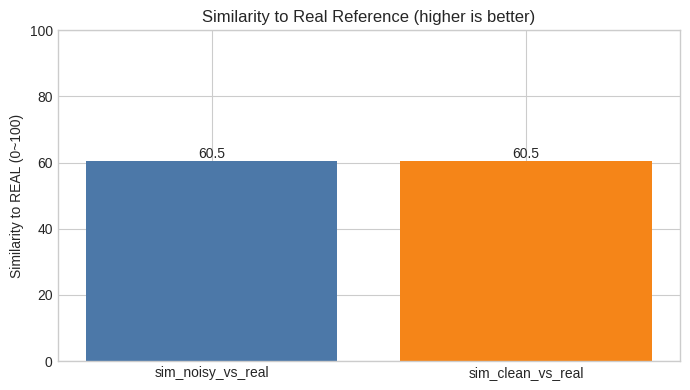

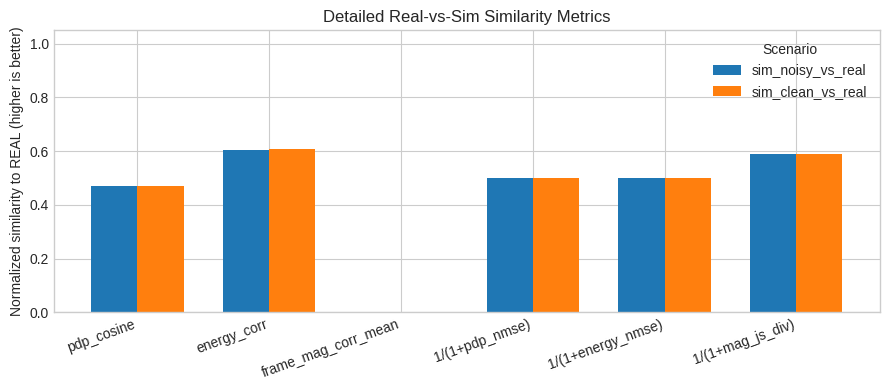

saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/00_overall_similarity_score.png
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/00_detailed_similarity_metrics.png


In [7]:
# ===== 유사도 상세 시각화 =====
import matplotlib.pyplot as plt
import numpy as np

label_map = {
    'h_cir_clean': 'sim_clean_vs_real',
    'h_cir_noisy': 'sim_noisy_vs_real',
}

plot_df = similarity_detail_df.copy()
plot_df['scenario_view'] = plot_df['scenario'].map(lambda x: label_map.get(x, f'sim_{x}_vs_real'))
plot_df = plot_df.set_index('scenario_view')

# 1) 종합 점수 바 차트
plt.figure(figsize=(7, 4))
plt.bar(plot_df.index, plot_df['overall_similarity_score'], color=['#4C78A8','#F58518'])
plt.ylim(0, 100)
plt.ylabel('Similarity to REAL (0~100)')
plt.title('Similarity to Real Reference (higher is better)')
for i, v in enumerate(plot_df['overall_similarity_score'].values):
    plt.text(i, v + 1.0, f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / "00_overall_similarity_score.png", dpi=150)
plt.show()

# 2) 핵심 지표 비교 (높을수록 좋게 변환)
view = pd.DataFrame(index=plot_df.index)
view['pdp_cosine'] = plot_df['pdp_cosine']
view['energy_corr'] = plot_df['energy_corr']
view['frame_mag_corr_mean'] = plot_df['frame_mag_corr_mean']
view['1/(1+pdp_nmse)'] = 1.0 / (1.0 + plot_df['pdp_nmse'])
view['1/(1+energy_nmse)'] = 1.0 / (1.0 + plot_df['energy_nmse'])
view['1/(1+mag_js_div)'] = 1.0 / (1.0 + plot_df['mag_js_div'])

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(view.columns))
w = 0.35
for i, sc in enumerate(view.index):
    ax.bar(x + (i - 0.5) * w, view.loc[sc].values, width=w, label=sc)
ax.set_xticks(x)
ax.set_xticklabels(view.columns, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Normalized similarity to REAL (higher is better)')
ax.set_title('Detailed Real-vs-Sim Similarity Metrics')
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig(fig_dir / "00_detailed_similarity_metrics.png", dpi=150)
plt.show()

print("saved:", fig_dir / "00_overall_similarity_score.png")
print("saved:", fig_dir / "00_detailed_similarity_metrics.png")


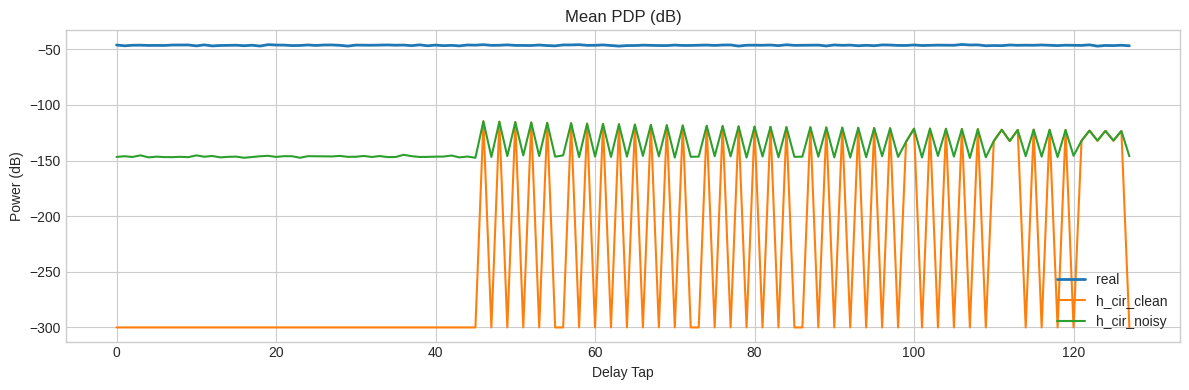

In [8]:
# ===== 이미지 1: mean PDP 비교 =====
def to_db(x):
    return 10.0 * np.log10(np.maximum(x, 1e-30))

real_pdp = np.mean(np.abs(real_cd)**2, axis=0)
plt.figure(figsize=(12,4))
plt.plot(to_db(real_pdp), label='real', linewidth=2)
for k in sim_keys:
    sim_pdp = np.mean(np.abs(sim_data[k]['arr_d'])**2, axis=0)
    plt.plot(to_db(sim_pdp), label=k)
plt.title('Mean PDP (dB)')
plt.xlabel('Delay Tap')
plt.ylabel('Power (dB)')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / '01_mean_pdp_compare.png', dpi=150)
plt.show()


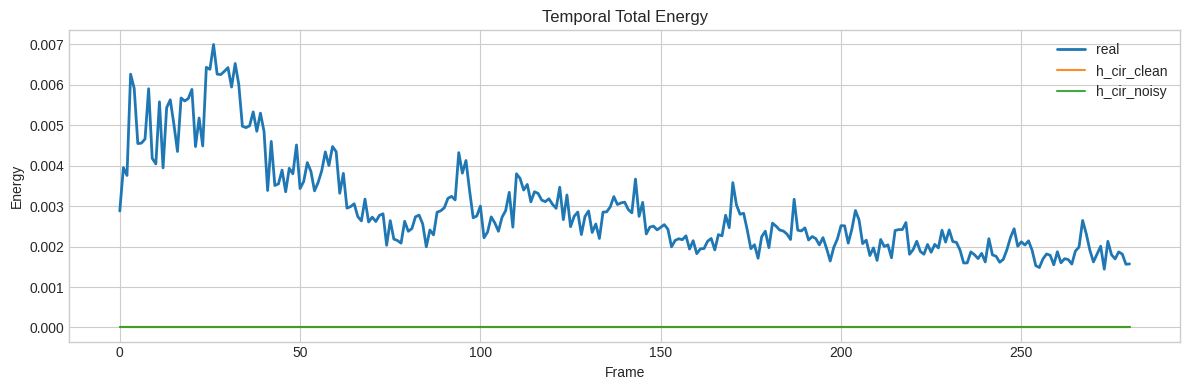

In [9]:
# ===== 이미지 2: 시간축 총 에너지 비교 =====
real_energy = np.sum(np.abs(real_cd)**2, axis=1)
plt.figure(figsize=(12,4))
plt.plot(real_energy, label='real', linewidth=2)
for k in sim_keys:
    sim_energy = np.sum(np.abs(sim_data[k]['arr_d'])**2, axis=1)
    plt.plot(sim_energy, label=k, alpha=0.9)
plt.title('Temporal Total Energy')
plt.xlabel('Frame')
plt.ylabel('Energy')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / '02_temporal_energy_compare.png', dpi=150)
plt.show()


## Step 3-1. 유사도 sanity check (너무 비슷한지 점검)

의문점이 맞습니다. 시뮬레이션이 real과 **완전히 같으면** 비정상(데이터 누수/복사)일 수 있습니다.
아래 셀은 누수 의심 여부를 빠르게 점검합니다.

- `mag_global_corr_aligned`: 같은 시각 정렬 기준 전역 magnitude 상관
- `mag_global_corr_shuffled`: real 프레임을 섞었을 때 상관(기준선)
- `near_identical_frac`: 프레임 상대오차가 매우 작은 비율
- `leakage_suspected`: 너무 유사할 때 경고


,scenario,mag_global_corr_aligned,mag_global_corr_shuffled,aligned_minus_shuffled,near_identical_frac,leakage_suspected
0,h_cir_clean,0.037032,0.030434,0.006598,0.0,False
1,h_cir_noisy,0.087063,0.075588,0.011474,0.0,False


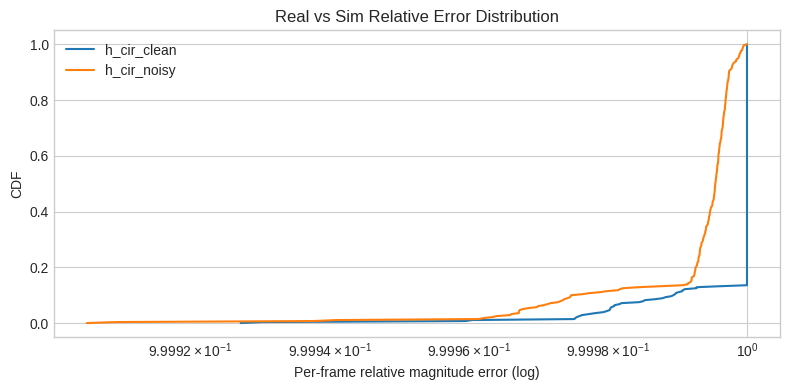

saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/00_sanity_relative_error_cdf.png


In [10]:
# ===== 유사도 sanity check: 너무 비슷한지(누수 의심) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed)
rows = []
rel_err_store = {}

for sc in sim_keys:
    sim = sim_data[sc]['arr_d']
    n = min(sim.shape[0], real_cd.shape[0])
    sim_n = sim[:n]
    real_n = real_cd[:n]

    sim_mag = np.abs(sim_n)
    real_mag = np.abs(real_n)

    # aligned correlation
    a = sim_mag.ravel()
    b = real_mag.ravel()
    aligned = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

    # shuffled baseline
    idx = rng.permutation(n)
    b_sh = real_mag[idx].ravel()
    shuffled = float(np.dot(a, b_sh) / (np.linalg.norm(a) * np.linalg.norm(b_sh) + 1e-12))

    # per-frame relative magnitude error
    rel_err = np.linalg.norm(sim_mag - real_mag, axis=1) / (np.linalg.norm(real_mag, axis=1) + 1e-12)
    rel_err_store[sc] = rel_err

    near_identical_frac = float(np.mean(rel_err < 1e-3))
    leakage_suspected = bool((aligned > 0.999) and (near_identical_frac > 0.90))

    rows.append({
        'scenario': sc,
        'mag_global_corr_aligned': aligned,
        'mag_global_corr_shuffled': shuffled,
        'aligned_minus_shuffled': aligned - shuffled,
        'near_identical_frac': near_identical_frac,
        'leakage_suspected': leakage_suspected,
    })

sanity_df = pd.DataFrame(rows)
display(sanity_df)

# 시각화: 상대오차 분포(CDF)
plt.figure(figsize=(8,4))
for sc in sim_keys:
    x = np.sort(rel_err_store[sc])
    y = np.linspace(0, 1, len(x), endpoint=True)
    plt.plot(x, y, label=sc)
plt.xscale('log')
plt.xlabel('Per-frame relative magnitude error (log)')
plt.ylabel('CDF')
plt.title('Real vs Sim Relative Error Distribution')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / '00_sanity_relative_error_cdf.png', dpi=150)
plt.show()

print('saved:', fig_dir / '00_sanity_relative_error_cdf.png')


## Step 3-2. frame=140 기준 CIR 유사도 지표 (10번 그림 기준)

기준 파형: **real frame=140, first 512 taps** (`10번 그림`)

시뮬레이션(`h_cir_clean`, `h_cir_noisy`)을 같은 프레임/탭에서 비교해 전용 점수를 계산합니다.

사용 지표:
- `raw_nmse_mag`: 절대 크기 |h| NMSE (작을수록 좋음)
- `shape_nmse_mag`: L2 정규화 후 |h| NMSE (모양 차이, 작을수록 좋음)
- `cosine_mag`, `corr_mag`: 파형 유사도 (클수록 좋음)
- `energy_ratio_db`: 총 에너지 비율(dB, 0에 가까울수록 좋음)
- `peak_delay_diff`: 피크 tap 차이 (작을수록 좋음)

종합 점수(0~100):
`score = 100*(0.35*C_cos + 0.25*C_shape + 0.15*C_raw + 0.15*C_energy + 0.10*C_peak)`

- `C_cos = clip((cosine+1)/2,0,1)`
- `C_shape = 1/(1+shape_nmse)`
- `C_raw = 1/(1+raw_nmse)`
- `C_energy = exp(-|energy_ratio_db|/6)`
- `C_peak = exp(-peak_delay_diff/50)`


,scenario,frame_idx,taps_used,raw_nmse_mag,raw_mae_mag,shape_nmse_mag,cosine_mag,corr_mag,energy_ratio_db,peak_delay_diff,C_cos,C_shape,C_raw,C_energy,C_peak,frame140_similarity_score
1,sim_h_cir_noisy_vs_real,140,128,0.999993,0.004403,0.459458,0.770215,-0.067328,-94.649176,35,0.885108,0.685186,0.500002,1.409497e-07,0.496585,60.574297
0,sim_h_cir_clean_vs_real,140,128,1.000000,0.004403,1.000000,0.000000,0.000000,-94.913303,67,0.500000,0.500000,0.500000,1.348795e-07,0.261846,40.118459


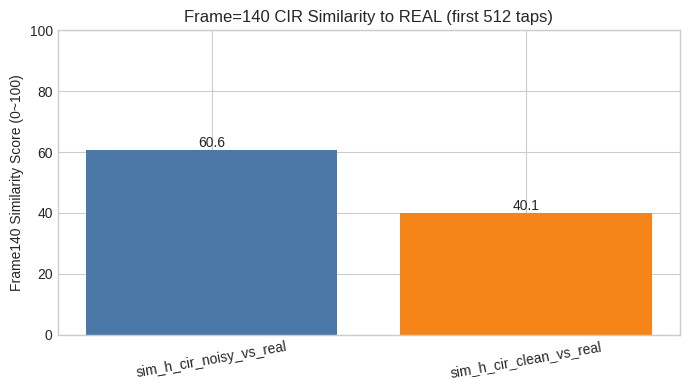

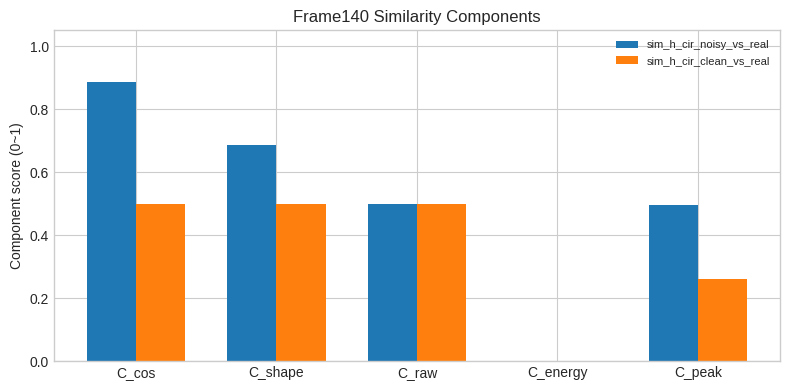

saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/16_frame140_similarity_score.png
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/17_frame140_similarity_components.png
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/frame140_similarity_metrics.csv


In [11]:
# ===== frame=140 기준 전용 유사도 지표 계산 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

frame_ref = 140
taps_ref = min(512, common_d)

def safe_corr(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0,1])

def frame140_metrics(real_c, sim_c, frame_idx=140, taps=512):
    n_frame = min(real_c.shape[0], sim_c.shape[0])
    fi = min(max(frame_idx, 0), n_frame - 1)
    t = min(taps, real_c.shape[1], sim_c.shape[1])

    r = np.abs(real_c[fi, :t]).astype(float)
    s = np.abs(sim_c[fi, :t]).astype(float)

    eps = 1e-12
    raw_nmse = float(np.mean((s-r)**2) / (np.mean(r**2) + eps))
    raw_mae = float(np.mean(np.abs(s-r)))
    corr = safe_corr(s, r)
    cos = float(np.dot(s, r) / (np.linalg.norm(s)*np.linalg.norm(r) + eps))

    rn = r / (np.linalg.norm(r) + eps)
    sn = s / (np.linalg.norm(s) + eps)
    shape_nmse = float(np.mean((sn-rn)**2) / (np.mean(rn**2) + eps))

    energy_ratio_db = float(10.0*np.log10((np.sum(s**2)+eps)/(np.sum(r**2)+eps)))
    peak_delay_diff = int(abs(int(np.argmax(s)) - int(np.argmax(r))))

    c_cos = np.clip((cos + 1.0)/2.0, 0.0, 1.0)
    c_shape = 1.0 / (1.0 + max(shape_nmse, 0.0))
    c_raw = 1.0 / (1.0 + max(raw_nmse, 0.0))
    c_energy = float(np.exp(-abs(energy_ratio_db)/6.0))
    c_peak = float(np.exp(-peak_delay_diff/50.0))

    score = 100.0 * (0.35*c_cos + 0.25*c_shape + 0.15*c_raw + 0.15*c_energy + 0.10*c_peak)

    return {
        "frame_idx": fi,
        "taps_used": t,
        "raw_nmse_mag": raw_nmse,
        "raw_mae_mag": raw_mae,
        "shape_nmse_mag": shape_nmse,
        "cosine_mag": cos,
        "corr_mag": corr,
        "energy_ratio_db": energy_ratio_db,
        "peak_delay_diff": peak_delay_diff,
        "C_cos": c_cos,
        "C_shape": c_shape,
        "C_raw": c_raw,
        "C_energy": c_energy,
        "C_peak": c_peak,
        "frame140_similarity_score": score,
    }

rows = []
for sc in sim_keys:
    m = frame140_metrics(real_cd, sim_data[sc]["arr_d"], frame_idx=frame_ref, taps=taps_ref)
    rows.append({"scenario": f"sim_{sc}_vs_real", **m})

frame140_df = pd.DataFrame(rows).sort_values("frame140_similarity_score", ascending=False)
display(frame140_df)

# bar: overall score
plt.figure(figsize=(7,4))
plt.bar(frame140_df["scenario"], frame140_df["frame140_similarity_score"], color=["#4C78A8", "#F58518"])
plt.ylim(0, 100)
plt.ylabel("Frame140 Similarity Score (0~100)")
plt.title("Frame=140 CIR Similarity to REAL (first 512 taps)")
for i,v in enumerate(frame140_df["frame140_similarity_score"].values):
    plt.text(i, v+1.0, f"{v:.1f}", ha="center", fontsize=10)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(fig_dir / "16_frame140_similarity_score.png", dpi=150)
plt.show()

# components (normalized)
comp_cols = ["C_cos","C_shape","C_raw","C_energy","C_peak"]
comp = frame140_df.set_index("scenario")[comp_cols]
fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(len(comp_cols))
w = 0.35
for i, sc in enumerate(comp.index):
    ax.bar(x + (i-0.5)*w, comp.loc[sc].values, width=w, label=sc)
ax.set_xticks(x)
ax.set_xticklabels(comp_cols)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Component score (0~1)")
ax.set_title("Frame140 Similarity Components")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(fig_dir / "17_frame140_similarity_components.png", dpi=150)
plt.show()

frame140_csv = fig_dir / "frame140_similarity_metrics.csv"
frame140_df.to_csv(frame140_csv, index=False)
print("saved:", fig_dir / "16_frame140_similarity_score.png")
print("saved:", fig_dir / "17_frame140_similarity_components.png")
print("saved:", frame140_csv)


## Step 4. 노이즈 튜닝 (clean sim -> synthetic noisy)

Step 4: 유사도 기반 노이즈 후보 탐색
Step 4-1: 유사도 + 검증 NMSE 목적함수로 best theta 자동 선택


### 참고
Step 4 셀에서 노이즈 후보를 만들고, Step 4-1 셀에서 자동 선택된 `best_theta`를 계산합니다.
Step 5는 이 `best_theta`를 자동으로 연결해 비교합니다.


,awgn_rel_db,phase_std_deg,amp_jitter_std_db,overall_similarity_score,pdp_cosine,energy_corr,frame_mag_corr_mean,pdp_nmse,energy_nmse,mag_js_div
51,-35,1.0,0.0,60.586828,0.482475,0.606551,-0.002216,0.998106,1.0,0.691101
54,-35,2.0,0.0,60.586815,0.482482,0.606543,-0.002217,0.998106,1.0,0.691101
57,-35,5.0,0.0,60.586671,0.482501,0.606508,-0.002218,0.998106,1.0,0.691101
48,-35,0.0,0.0,60.531053,0.480015,0.602268,-0.002166,0.998106,1.0,0.691101
39,-40,1.0,0.0,60.511843,0.473358,0.606708,-0.002255,0.998106,1.0,0.691101
42,-40,2.0,0.0,60.511826,0.473362,0.606703,-0.002255,0.998106,1.0,0.691101
45,-40,5.0,0.0,60.511713,0.473370,0.606682,-0.002256,0.998106,1.0,0.691101
27,-45,1.0,0.0,60.487793,0.470475,0.606726,-0.002275,0.998106,1.0,0.691101
30,-45,2.0,0.0,60.487781,0.470477,0.606723,-0.002275,0.998106,1.0,0.691101
33,-45,5.0,0.0,60.487709,0.470481,0.606710,-0.002275,0.998106,1.0,0.691101


Best params:
awgn_rel_db                -35.000000
phase_std_deg                1.000000
amp_jitter_std_db            0.000000
overall_similarity_score    60.586828
Name: 51, dtype: float64


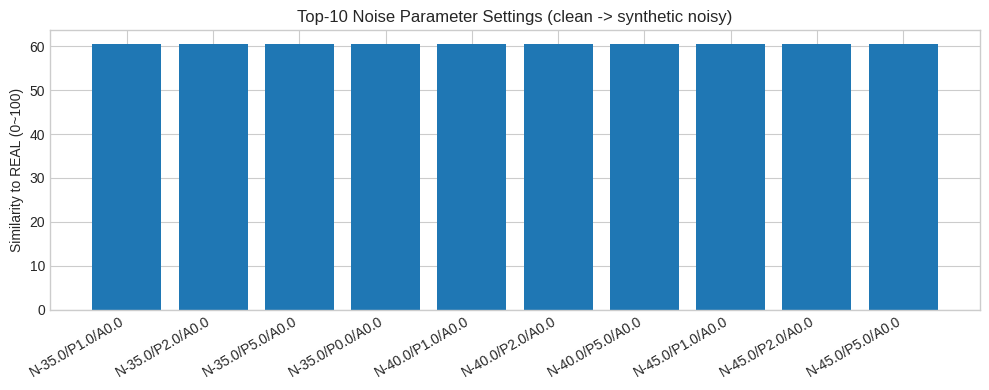

saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/00_noise_sweep_top10.png
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/noise_sweep_similarity.csv


In [12]:
# ===== clean->synthetic noisy 유사도 탐색 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def inject_noise_like_measurement(h_clean, awgn_rel_db=-45.0, phase_std_deg=0.0, amp_jitter_std_db=0.0, seed=1234):
    rng = np.random.default_rng(seed)
    h = np.array(h_clean, dtype=np.complex128, copy=True)

    # Frame-wise amplitude/phase jitter
    if amp_jitter_std_db > 0.0:
        amp_db = rng.normal(0.0, amp_jitter_std_db, size=(h.shape[0], 1))
        h = h * (10.0 ** (amp_db / 20.0))
    if phase_std_deg > 0.0:
        phi = rng.normal(0.0, np.deg2rad(phase_std_deg), size=(h.shape[0], 1))
        h = h * np.exp(1j * phi)

    # Complex AWGN relative to per-frame peak power
    peak_p = np.max(np.abs(h)**2, axis=1, keepdims=True)
    noise_p = np.maximum(peak_p, 1e-30) * (10.0 ** (awgn_rel_db / 10.0))
    sigma = np.sqrt(noise_p / 2.0)
    n_re = rng.normal(0.0, 1.0, size=h.shape) * sigma
    n_im = rng.normal(0.0, 1.0, size=h.shape) * sigma
    return h + (n_re + 1j * n_im)

def compute_similarity_score(sim_arr, real_arr):
    base = mod.similarity_metrics(sim_arr, real_arr)
    real_pdp = np.mean(np.abs(real_arr) ** 2, axis=0)
    sim_pdp = np.mean(np.abs(sim_arr) ** 2, axis=0)
    pdp_cos = cosine_sim(sim_pdp, real_pdp)
    frame_mean, frame_std = framewise_mag_corr_stats(real_arr, sim_arr)
    mag_js = js_divergence_from_hist(np.abs(sim_arr).ravel(), np.abs(real_arr).ravel())
    score = score_from_metrics(
        pdp_cosine=pdp_cos,
        energy_corr=base['energy_corr'],
        frame_corr_mean=frame_mean,
        pdp_nmse=base['pdp_nmse'],
        energy_nmse=base['energy_nmse'],
        mag_js_div=mag_js,
    )
    return {
        'overall_similarity_score': score,
        'pdp_cosine': pdp_cos,
        'energy_corr': base['energy_corr'],
        'frame_mag_corr_mean': frame_mean,
        'pdp_nmse': base['pdp_nmse'],
        'energy_nmse': base['energy_nmse'],
        'mag_js_div': mag_js,
    }

clean = sim_data['h_cir_clean']['arr_d']
real_ref = real_cd[:clean.shape[0]]

awgn_grid = [-55, -50, -45, -40, -35]
phase_grid = [0.0, 1.0, 2.0, 5.0]
amp_grid = [0.0, 0.5, 1.0]

rows = []
for awgn in awgn_grid:
    for ph in phase_grid:
        for amp in amp_grid:
            sim_syn = inject_noise_like_measurement(clean, awgn_rel_db=awgn, phase_std_deg=ph, amp_jitter_std_db=amp, seed=seed)
            mm = compute_similarity_score(sim_syn, real_ref)
            rows.append({
                'awgn_rel_db': awgn,
                'phase_std_deg': ph,
                'amp_jitter_std_db': amp,
                **mm,
            })

noise_sweep_df = pd.DataFrame(rows).sort_values('overall_similarity_score', ascending=False)
display(noise_sweep_df.head(10))

best = noise_sweep_df.iloc[0]
print('Best params:')
print(best[['awgn_rel_db','phase_std_deg','amp_jitter_std_db','overall_similarity_score']])

# 시각화: 상위 10개 설정 점수
top10 = noise_sweep_df.head(10).copy()
labels = [f"N{r.awgn_rel_db}/P{r.phase_std_deg}/A{r.amp_jitter_std_db}" for _, r in top10.iterrows()]
plt.figure(figsize=(10,4))
plt.bar(np.arange(len(top10)), top10['overall_similarity_score'])
plt.xticks(np.arange(len(top10)), labels, rotation=30, ha='right')
plt.ylabel('Similarity to REAL (0~100)')
plt.title('Top-10 Noise Parameter Settings (clean -> synthetic noisy)')
plt.tight_layout()
plt.savefig(fig_dir / '00_noise_sweep_top10.png', dpi=150)
plt.show()

noise_sweep_csv = fig_dir / 'noise_sweep_similarity.csv'
noise_sweep_df.to_csv(noise_sweep_csv, index=False)
print('saved:', fig_dir / '00_noise_sweep_top10.png')
print('saved:', noise_sweep_csv)


## Step 4-1. 자동 노이즈 선택 (유사도 + 검증 NMSE)

노이즈 파라미터를 **유사도만**으로 고르지 않고, real 검증 성능까지 함께 반영합니다.

목적함수:
`J(θ) = λ * (SimilarityScore/100) + (1-λ) * (1/(1+Val_NMSE))`

- `θ = [awgn_rel_db, phase_std_deg, amp_jitter_std_db]`
- `SimilarityScore`: Step4에서 계산한 점수
- `Val_NMSE`: real validation 구간 NMSE (Ridge 기준)
- `J`가 클수록 좋음


split: total=273, tune=68, val=102, test=103


,awgn_rel_db,phase_std_deg,amp_jitter_std_db,similarity_score,val_nmse_ridge,J_objective
0,-35.0,2.0,0.0,60.586815,1.276537,0.539226
1,-35.0,1.0,0.0,60.586828,1.276829,0.539204
2,-35.0,5.0,0.0,60.586671,1.276963,0.539193
3,-35.0,0.0,0.5,60.321872,1.271699,0.538011
4,-35.0,5.0,0.5,60.331868,1.298935,0.535985
5,-35.0,2.0,0.5,60.330983,1.300883,0.535832
6,-35.0,0.0,1.0,59.898501,1.267148,0.535824
7,-35.0,1.0,0.5,60.330681,1.301603,0.535776
8,-35.0,5.0,1.0,59.876546,1.294488,0.533590
9,-35.0,2.0,1.0,59.875678,1.296397,0.533440



[best theta by J]
awgn_rel_db         -35.000000
phase_std_deg         2.000000
amp_jitter_std_db     0.000000
similarity_score     60.586815
val_nmse_ridge        1.276537
J_objective           0.539226
Name: 0, dtype: float64


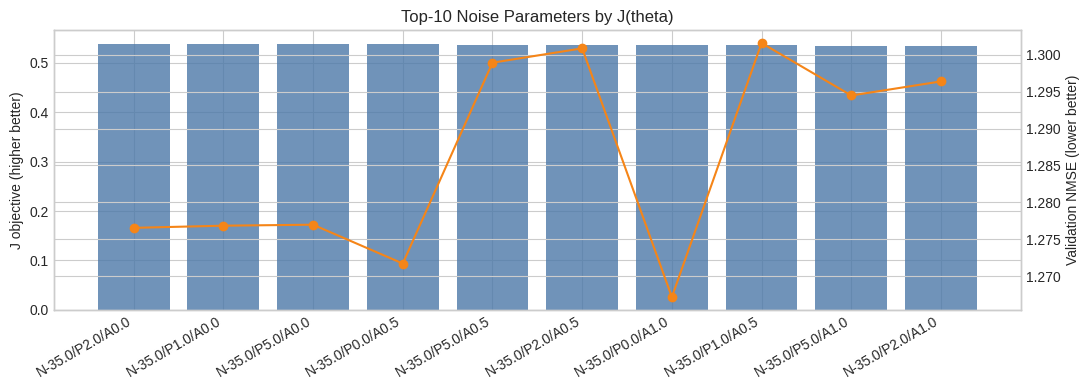

[best theta test ridge] {'mse': 2.1246969396837464e-05, 'mae': 0.004012137328441496, 'nmse': 1.3381532998504337}
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/18_noise_selection_objective.png
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/noise_selection_objective.csv


In [13]:
# ===== 자동 노이즈 선택: J(theta) 최적화 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 가중치: 유사도 vs 예측 성능
lambda_similarity = 0.6

# 실시간 분할: tune / val / test
real_feat = mod.complex_to_features(real_cd)
x_real, y_real = mod.make_windows(real_feat, window, horizon)

n_total = x_real.shape[0]
n_tune = int(round(n_total * calib_ratio))
n_tune = max(1, min(n_total - 2, n_tune))

x_tune, y_tune = x_real[:n_tune], y_real[:n_tune]
x_rest, y_rest = x_real[n_tune:], y_real[n_tune:]
n_val = max(1, len(x_rest)//2)
x_val, y_val = x_rest[:n_val], y_rest[:n_val]
x_test, y_test = x_rest[n_val:], y_rest[n_val:]

print(f"split: total={n_total}, tune={len(x_tune)}, val={len(x_val)}, test={len(x_test)}")

# candidate list: Step4 sweep 결과 재사용
if "noise_sweep_df" not in globals():
    raise RuntimeError("먼저 Step4 셀(clean->synthetic noisy 유사도 탐색)을 실행하세요.")

cand_df = noise_sweep_df[["awgn_rel_db","phase_std_deg","amp_jitter_std_db","overall_similarity_score"]].copy()
cand_df = cand_df.drop_duplicates(subset=["awgn_rel_db","phase_std_deg","amp_jitter_std_db"])

rows = []
y_val_c = mod.features_to_complex(y_val)

for _, r in cand_df.iterrows():
    awgn = float(r.awgn_rel_db)
    ph = float(r.phase_std_deg)
    amp = float(r.amp_jitter_std_db)
    sim_score = float(r.overall_similarity_score)

    # clean -> synthetic noisy
    sim_syn = inject_noise_like_measurement(
        sim_data["h_cir_clean"]["arr_d"],
        awgn_rel_db=awgn, phase_std_deg=ph, amp_jitter_std_db=amp, seed=seed
    )

    sim_feat = mod.complex_to_features(sim_syn)
    x_sim, y_sim = mod.make_windows(sim_feat, window, horizon)

    # Ridge 기준 validation NMSE
    y_val_pred = mod.train_ridge_predict(
        x_sim=x_sim, y_sim=y_sim,
        x_cal=x_tune, y_cal=y_tune,
        x_eval=x_val, alpha=ridge_alpha,
    )
    m_val = mod.eval_prediction(y_val_c, mod.features_to_complex(y_val_pred))
    val_nmse = float(m_val["nmse"])

    # objective
    sim_term = sim_score / 100.0
    pred_term = 1.0 / (1.0 + max(val_nmse, 0.0))
    J = lambda_similarity * sim_term + (1.0 - lambda_similarity) * pred_term

    rows.append({
        "awgn_rel_db": awgn,
        "phase_std_deg": ph,
        "amp_jitter_std_db": amp,
        "similarity_score": sim_score,
        "val_nmse_ridge": val_nmse,
        "J_objective": J,
    })

noise_select_df = pd.DataFrame(rows).sort_values("J_objective", ascending=False).reset_index(drop=True)
display(noise_select_df.head(10))

best_theta = noise_select_df.iloc[0]
print("\n[best theta by J]")
print(best_theta)

# 시각화
top = noise_select_df.head(10).copy()
labels = [f"N{r.awgn_rel_db}/P{r.phase_std_deg}/A{r.amp_jitter_std_db}" for _, r in top.iterrows()]
x = np.arange(len(top))

fig, ax1 = plt.subplots(figsize=(11,4))
ax1.bar(x, top["J_objective"], color="#4C78A8", alpha=0.8, label="J objective")
ax1.set_ylabel("J objective (higher better)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_title("Top-10 Noise Parameters by J(theta)")

ax2 = ax1.twinx()
ax2.plot(x, top["val_nmse_ridge"].values, color="#F58518", marker="o", label="val_nmse_ridge")
ax2.set_ylabel("Validation NMSE (lower better)")

fig.tight_layout()
plt.savefig(fig_dir / "18_noise_selection_objective.png", dpi=150)
plt.show()

# best theta로 test 성능 확인(Ridge)
best_sim = inject_noise_like_measurement(
    sim_data["h_cir_clean"]["arr_d"],
    awgn_rel_db=float(best_theta.awgn_rel_db),
    phase_std_deg=float(best_theta.phase_std_deg),
    amp_jitter_std_db=float(best_theta.amp_jitter_std_db),
    seed=seed,
)
x_sim_best, y_sim_best = mod.make_windows(mod.complex_to_features(best_sim), window, horizon)

if len(x_test) > 0:
    y_test_pred = mod.train_ridge_predict(
        x_sim=x_sim_best, y_sim=y_sim_best,
        x_cal=x_tune, y_cal=y_tune,
        x_eval=x_test, alpha=ridge_alpha,
    )
    m_test = mod.eval_prediction(mod.features_to_complex(y_test), mod.features_to_complex(y_test_pred))
    print("[best theta test ridge]", m_test)

noise_select_csv = fig_dir / "noise_selection_objective.csv"
noise_select_df.to_csv(noise_select_csv, index=False)
print("saved:", fig_dir / "18_noise_selection_objective.png")
print("saved:", noise_select_csv)


## Step 5. 예측 성능 비교 (전통 vs AI)

- 기본 시나리오: `h_cir_clean`, `h_cir_noisy`
- 추가 시나리오: Step 4-1의 `best_theta`가 있으면 `sim_tuned_from_clean` 자동 포함


In [14]:
# ===== 예측 평가 함수 + 시나리오 구성 =====
def evaluate_one_scenario(sim_complex, scenario_name, seed=1234):
    sim_f = mod.complex_to_features(sim_complex)
    real_f = mod.complex_to_features(real_cd)

    x_sim, y_sim = mod.make_windows(sim_f, window, horizon)
    x_real, y_real = mod.make_windows(real_f, window, horizon)

    n = x_real.shape[0]
    n_cal = int(round(n * calib_ratio))
    n_cal = max(0, min(n - 1, n_cal))

    x_cal = x_real[:n_cal]
    y_cal = y_real[:n_cal]
    x_eval = x_real[n_cal:]
    y_eval = y_real[n_cal:]

    y_true_c = mod.features_to_complex(y_eval)
    fdim = y_real.shape[1]

    # Persistence
    y_persist_eval = x_eval.reshape(-1, window, fdim)[:, -1, :]
    m_persist = mod.eval_prediction(y_true_c, mod.features_to_complex(y_persist_eval))

    # Linear Ridge
    y_ridge_eval = mod.train_ridge_predict(
        x_sim=x_sim, y_sim=y_sim,
        x_cal=x_cal, y_cal=y_cal,
        x_eval=x_eval, alpha=ridge_alpha,
    )
    m_ridge = mod.eval_prediction(y_true_c, mod.features_to_complex(y_ridge_eval))

    # AI-MLP
    y_mlp_eval = mod.train_mlp_predict(
        x_sim=x_sim, y_sim=y_sim,
        x_cal=x_cal, y_cal=y_cal,
        x_eval=x_eval,
        hidden=mlp_hidden,
        epochs=mlp_epochs,
        fine_tune_epochs=mlp_fine_tune_epochs,
        batch_size=mlp_batch_size,
        lr=mlp_lr,
        clip=mlp_input_clip,
        seed=seed,
    )
    m_mlp = mod.eval_prediction(y_true_c, mod.features_to_complex(y_mlp_eval))

    rows = []
    for model, mm in [('Persistence', m_persist), ('LinearRidge', m_ridge), ('AI-MLP', m_mlp)]:
        rows.append({
            'scenario': scenario_name,
            'model': model,
            'mse': mm['mse'],
            'mae': mm['mae'],
            'nmse': mm['nmse'],
            'nmse_improve_vs_persistence_pct': 0.0 if model == 'Persistence' else 100.0*(1.0 - mm['nmse']/(m_persist['nmse']+1e-12)),
        })

    return {
        'rows': rows,
        'y_true_c': y_true_c,
        'pred': {
            'Persistence': mod.features_to_complex(y_persist_eval),
            'LinearRidge': mod.features_to_complex(y_ridge_eval),
            'AI-MLP': mod.features_to_complex(y_mlp_eval),
        },
        'x_eval': x_eval,
        'n_cal': n_cal,
        'n_eval': x_eval.shape[0],
    }


def build_eval_scenarios(seed=1234):
    # Return dict[name] -> complex CIR(time, delay), including tuned scenario if available.
    scenarios = {k: sim_data[k]['arr_d'] for k in sim_keys}

    # Connect Step4-1 result automatically
    if 'best_theta' in globals() and 'inject_noise_like_measurement' in globals():
        tuned = inject_noise_like_measurement(
            sim_data['h_cir_clean']['arr_d'],
            awgn_rel_db=float(best_theta['awgn_rel_db']),
            phase_std_deg=float(best_theta['phase_std_deg']),
            amp_jitter_std_db=float(best_theta['amp_jitter_std_db']),
            seed=seed,
        )
        scenarios['sim_tuned_from_clean'] = tuned
    return scenarios


In [15]:
# ===== 시나리오별 예측 성능 계산 (best_theta 자동 연동) =====
results = {}
metric_rows = []

scenario_inputs = build_eval_scenarios(seed=seed)
scenario_order = list(scenario_inputs.keys())

for sc, arr in scenario_inputs.items():
    out = evaluate_one_scenario(arr, sc, seed=seed)
    results[sc] = out
    metric_rows.extend(out['rows'])

metrics_df = pd.DataFrame(metric_rows).sort_values(['scenario', 'model'])
print('evaluated scenarios:', scenario_order)
metrics_df


2026-03-05 11:44:02.431441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772678642.445921 2457121 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772678642.450439 2457121 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772678642.462005 2457121 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772678642.462018 2457121 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772678642.462020 2457121 computation_placer.cc:177] computation placer alr

evaluated scenarios: ['h_cir_clean', 'h_cir_noisy', 'sim_tuned_from_clean']


2026-03-05 11:44:34.808877: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,scenario,model,mse,mae,nmse,nmse_improve_vs_persistence_pct
2,h_cir_clean,AI-MLP,73.281715,5.788271,3.949626e+06,-1.973588e+08
1,h_cir_clean,LinearRidge,0.000027,0.004394,1.447320e+00,2.767886e+01
0,h_cir_clean,Persistence,0.000037,0.005367,2.001240e+00,0.000000e+00
5,h_cir_noisy,AI-MLP,0.000019,0.003805,1.000867e+00,4.998767e+01
4,h_cir_noisy,LinearRidge,0.000053,0.005687,2.869100e+00,-4.336610e+01
3,h_cir_noisy,Persistence,0.000037,0.005367,2.001240e+00,0.000000e+00
8,sim_tuned_from_clean,AI-MLP,0.000019,0.003805,1.001085e+00,4.997676e+01
7,sim_tuned_from_clean,LinearRidge,0.000024,0.004275,1.303030e+00,3.488888e+01
6,sim_tuned_from_clean,Persistence,0.000037,0.005367,2.001240e+00,0.000000e+00


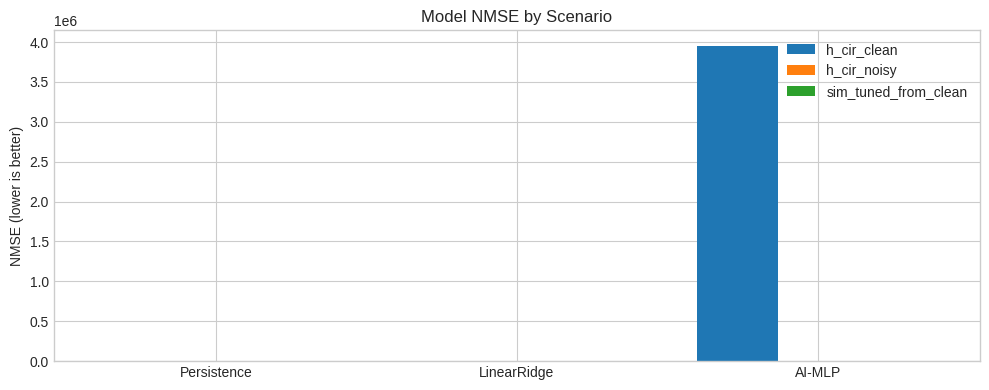

In [16]:
# ===== 이미지 3: NMSE 바 차트 =====
plt.figure(figsize=(10,4))
plot_df = metrics_df.copy()
models = ['Persistence', 'LinearRidge', 'AI-MLP']
bar_w = 0.8 / max(1, len(scenario_order))
x = np.arange(len(models))

for i, sc in enumerate(scenario_order):
    vals = [float(plot_df[(plot_df['scenario']==sc) & (plot_df['model']==m)]['nmse'].iloc[0]) for m in models]
    shift = (i - (len(scenario_order)-1)/2.0) * bar_w
    plt.bar(x + shift, vals, width=bar_w, label=sc)

plt.xticks(x, models)
plt.ylabel('NMSE (lower is better)')
plt.title('Model NMSE by Scenario')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / '03_nmse_bar_compare.png', dpi=150)
plt.show()


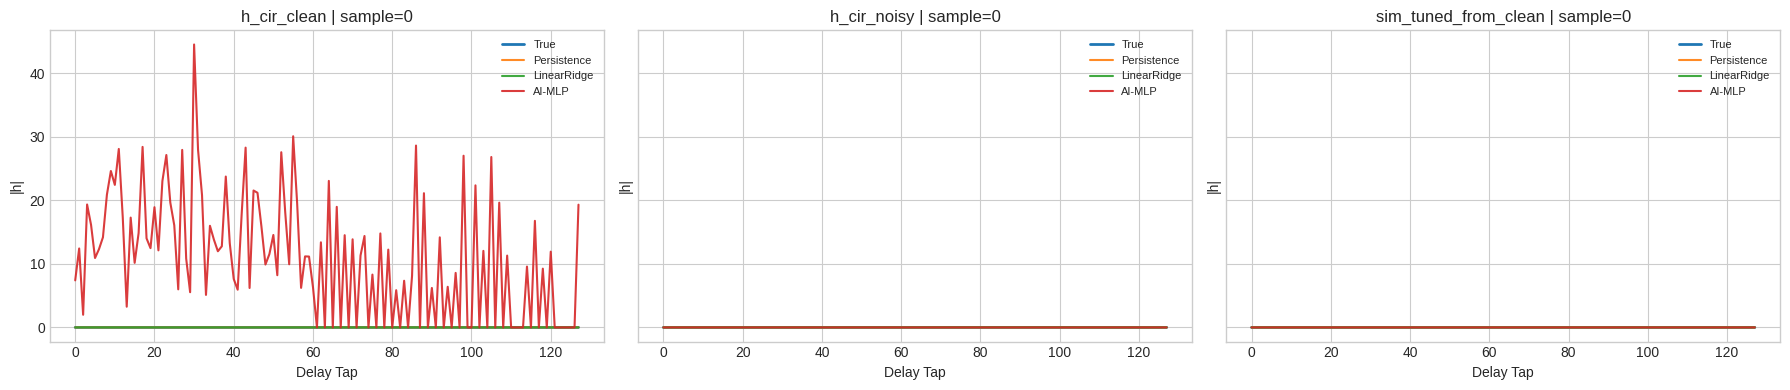

In [17]:
# ===== 이미지 4: 특정 샘플 예측 곡선 비교 =====
sample_idx = 0  # eval 구간 내 샘플 인덱스
plot_taps = min(128, common_d)

fig, axes = plt.subplots(1, len(scenario_order), figsize=(6*len(scenario_order), 4), sharey=True)
if len(scenario_order) == 1:
    axes = [axes]

for ax, sc in zip(axes, scenario_order):
    y_true = np.abs(results[sc]['y_true_c'][sample_idx, :plot_taps])
    ax.plot(y_true, label='True', linewidth=2)
    for model in ['Persistence', 'LinearRidge', 'AI-MLP']:
        y_pred = np.abs(results[sc]['pred'][model][sample_idx, :plot_taps])
        ax.plot(y_pred, label=model, alpha=0.9)
    ax.set_title(f'{sc} | sample={sample_idx}')
    ax.set_xlabel('Delay Tap')
    ax.set_ylabel('|h|')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / '04_sample_prediction_compare.png', dpi=150)
plt.show()


## Step 6. 반복 실험(선택) 및 저장


In [18]:
# ===== (선택) seed 반복 실험: 평균±표준편차 =====
seeds = [1234, 1235, 1236, 1237, 1238]
multi_rows = []

for sd in seeds:
    scenario_inputs_seed = build_eval_scenarios(seed=sd)
    for sc, arr in scenario_inputs_seed.items():
        out = evaluate_one_scenario(arr, sc, seed=sd)
        for r in out['rows']:
            r2 = dict(r)
            r2['seed'] = sd
            multi_rows.append(r2)

multi_df = pd.DataFrame(multi_rows)
agg = (
    multi_df
    .groupby(['scenario', 'model'], as_index=False)
    .agg(
        nmse_mean=('nmse', 'mean'), nmse_std=('nmse', 'std'),
        mse_mean=('mse', 'mean'), mse_std=('mse', 'std'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
        improve_mean=('nmse_improve_vs_persistence_pct', 'mean'),
        improve_std=('nmse_improve_vs_persistence_pct', 'std'),
    )
)
agg


2026-03-05 11:44:42.295086: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


2026-03-05 11:44:53.520203: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-03-05 11:44:59.077835: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

,scenario,model,nmse_mean,nmse_std,mse_mean,mse_std,mae_mean,mae_std,improve_mean,improve_std
0,h_cir_clean,AI-MLP,5.403615e+06,1.110633e+06,100.259153,2.060678e+01,6.695592,6.698614e-01,-2.700132e+08,5.549723e+07
1,h_cir_clean,LinearRidge,1.447320e+00,0.000000e+00,0.000027,0.000000e+00,0.004394,0.000000e+00,2.767886e+01,0.000000e+00
2,h_cir_clean,Persistence,2.001240e+00,0.000000e+00,0.000037,0.000000e+00,0.005367,0.000000e+00,0.000000e+00,0.000000e+00
3,h_cir_noisy,AI-MLP,1.001287e+00,3.518764e-04,0.000019,6.528746e-09,0.003806,9.062394e-07,4.996666e+01,1.758292e-02
4,h_cir_noisy,LinearRidge,2.869100e+00,0.000000e+00,0.000053,0.000000e+00,0.005687,0.000000e+00,-4.336610e+01,0.000000e+00
5,h_cir_noisy,Persistence,2.001240e+00,0.000000e+00,0.000037,0.000000e+00,0.005367,0.000000e+00,0.000000e+00,0.000000e+00
6,sim_tuned_from_clean,AI-MLP,1.001718e+00,5.388711e-04,0.000019,9.998263e-09,0.003806,1.299010e-06,4.994515e+01,2.692686e-02
7,sim_tuned_from_clean,LinearRidge,1.307503e+00,5.964053e-03,0.000024,1.106576e-07,0.004281,8.617281e-06,3.466534e+01,2.980179e-01
8,sim_tuned_from_clean,Persistence,2.001240e+00,0.000000e+00,0.000037,0.000000e+00,0.005367,0.000000e+00,0.000000e+00,0.000000e+00


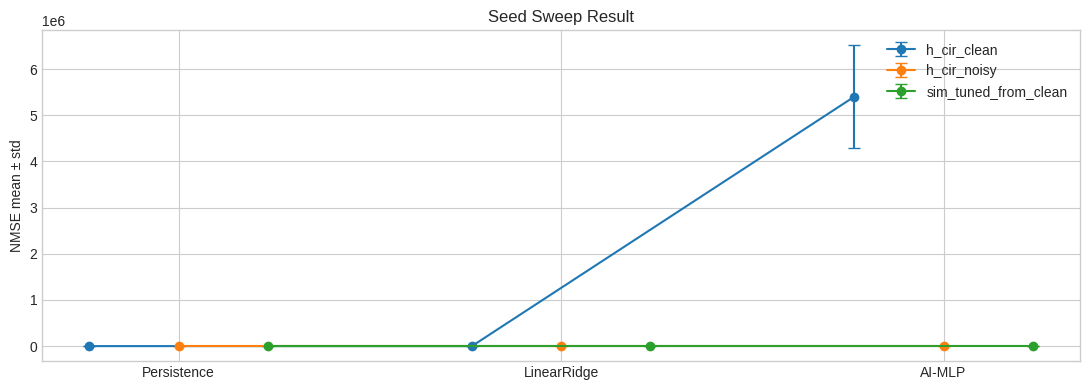

In [19]:
# ===== 이미지 5: seed 반복 NMSE 에러바 =====
if 'agg' in globals():
    plt.figure(figsize=(11,4))
    models = ['Persistence', 'LinearRidge', 'AI-MLP']
    x = np.arange(len(models))
    n_scen = agg['scenario'].nunique()
    off = 0.35 / max(1, n_scen)

    scenario_plot_order = sorted(agg['scenario'].unique())
    for i, sc in enumerate(scenario_plot_order):
        sub = agg[agg['scenario']==sc].set_index('model').reindex(models)
        means = sub['nmse_mean'].values
        stds = sub['nmse_std'].fillna(0.0).values
        shift = (i - (len(scenario_plot_order)-1)/2.0) * (2*off)
        plt.errorbar(x + shift, means, yerr=stds, fmt='o-', capsize=4, label=sc)

    plt.xticks(x, models)
    plt.ylabel('NMSE mean ± std')
    plt.title('Seed Sweep Result')
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / '05_seed_sweep_nmse_errorbar.png', dpi=150)
    plt.show()


In [20]:
# ===== 결과 저장 =====
metrics_csv = fig_dir / 'metrics_single_seed.csv'
metrics_df.to_csv(metrics_csv, index=False)
print('saved:', metrics_csv)

if 'multi_df' in globals():
    multi_csv = fig_dir / 'metrics_multi_seed_raw.csv'
    agg_csv = fig_dir / 'metrics_multi_seed_agg.csv'
    multi_df.to_csv(multi_csv, index=False)
    agg.to_csv(agg_csv, index=False)
    print('saved:', multi_csv)
    print('saved:', agg_csv)


saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/metrics_single_seed.csv
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/metrics_multi_seed_raw.csv
saved: /home/mh/kmh/sionna-rt/jinsup/realVSsim/metrics_multi_seed_agg.csv
